In [2]:
import Kea
from Kea.utils import plotting, funcs
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

D = 2
N = 1024
L = 5.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L
dx = L/N

0.001298745924880457


/tmp/ipykernel_14395/1828733458.py:7: RuntimeWarning: divide by zero encountered in true_divide
  f = np.exp(-(k/kb1)**2) * np.exp(-(kb2/k)**2) * k**(-a)
/tmp/ipykernel_14395/1828733458.py:7: RuntimeWarning: divide by zero encountered in power
  f = np.exp(-(k/kb1)**2) * np.exp(-(kb2/k)**2) * k**(-a)
/tmp/ipykernel_14395/1828733458.py:7: RuntimeWarning: invalid value encountered in multiply
  f = np.exp(-(k/kb1)**2) * np.exp(-(kb2/k)**2) * k**(-a)


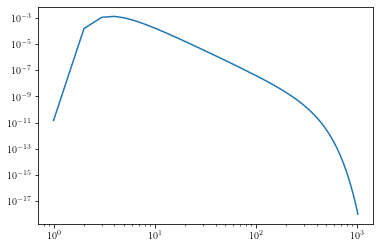

In [13]:
k = np.linspace(0, 1024, 1024)

a = 11./3
kb1 = 256.
kb2 = 5.

f = np.exp(-(k/kb1)**2) * np.exp(-(kb2/k)**2) * k**(-a)

print(np.nanmax(f))

plt.loglog(k, f)
#plt.ylim(())


In [5]:
from scipy.special import jv
import sympy as sp
sp.init_printing(use_latex='mathjax')

k = sp.symbols('k', postive=True, real=True)

sp_D = sp.symbols('D', positive=True, integer=True)
sp_D = 2

sp_L = sp.symbols('L', positive=True, real=True)
sp_L = 4*sp.pi
sp_N = sp.symbols('N', positive=True, integer=True)
sp_N = 256

sp_kmin = (sp.S(2)*sp.pi/sp_L)
sp_kmax = (sp.pi*sp_N/sp_L)

b = 5*sp_kmin

sp_E = sp.Piecewise(
    (0, k == 0),
    (0, k > sp_kmax),
    ((k/b)**(-11/3)*sp.exp(-2*(k/b)**2), True)
)

norm = sp.S(1)/(sp.S(2)*sp.pi)**sp_D

sig = norm * sp.integrate(sp.S(2) * (sp.S(2) * sp.pi * k * sp_E), (k, 0, sp.oo))
Ef = sp_E / sig
display(sig)

s = sp.symbols('sigma', real=True, positive=True)
xi = sp.symbols('xi', real=True, positive=True)

Hk = k**2 * s**2 * xi * sp.exp(- k**2 * s**2 / 2)

S_D = sp.S(2)*sp.pi**(sp_D/2)/sp.gamma(sp_D/2)

Vs_num = sp.S(2) * norm * sp.integrate((S_D * k**(sp_D-1)) * Ef * sp.Abs(Hk)**2, (k, 0, sp.oo))

Vs_denom = sp.S(2) * norm * sp.integrate((S_D * k**(sp_D-1)) * sp.Abs(Hk)**2, (k, 0, sp.oo))
Vs = Vs_num / Vs_denom

display(Vs)


                  ⎛                   ⅈ⋅π  32768⎞
5.56811698837712⋅γ⎜0.833333333333333⋅ℯ   , ─────⎟
                  ⎝                          25 ⎠
─────────────────────────────────────────────────
                        π                        

                                    -1.16666666666667                         
                  1.0  6 ⎛    2    ⎞                   ⎛                      
110.485434560398⋅π   ⋅σ ⋅⎝25⋅σ  + 8⎠                 ⋅γ⎜1.16666666666667, 4096
                                                       ⎝                      
──────────────────────────────────────────────────────────────────────────────
                              ⎛                   ⅈ⋅π  32768⎞                 
                             γ⎜0.833333333333333⋅ℯ   , ─────⎟                 
                              ⎝                          25 ⎠                 

            
  2   32768⎞
⋅σ  + ─────⎟
        25 ⎠
────────────
            
            
            

In [6]:

# import mpmath

# integrand = lambda k_, s_: (np.pi*s_**6) * (k_**(-4./3.)*np.exp(-k_)*np.exp(-k_**2 * s_**2)) / (mpmath.gammainc(-5./3., sp_kmax.evalf()))

# from scipy.integrate import quad
# intensity = lambda s_: quad(lambda k_: integrand(k_, s_), 0, float(sp_kmax.evalf()))[0]

# _kk = np.exp(np.linspace(np.log(float(sp_kmin.evalf())), np.log(float(sp_kmax.evalf())), 100))
# _ss = np.sqrt(10.)/(2.*_kk)

# plt.plot(_ss, np.vectorize(intensity)(_ss))
# plt.xscale('log')

# #plt.ylim((0,1))


TypeError: return arrays must be of ArrayType

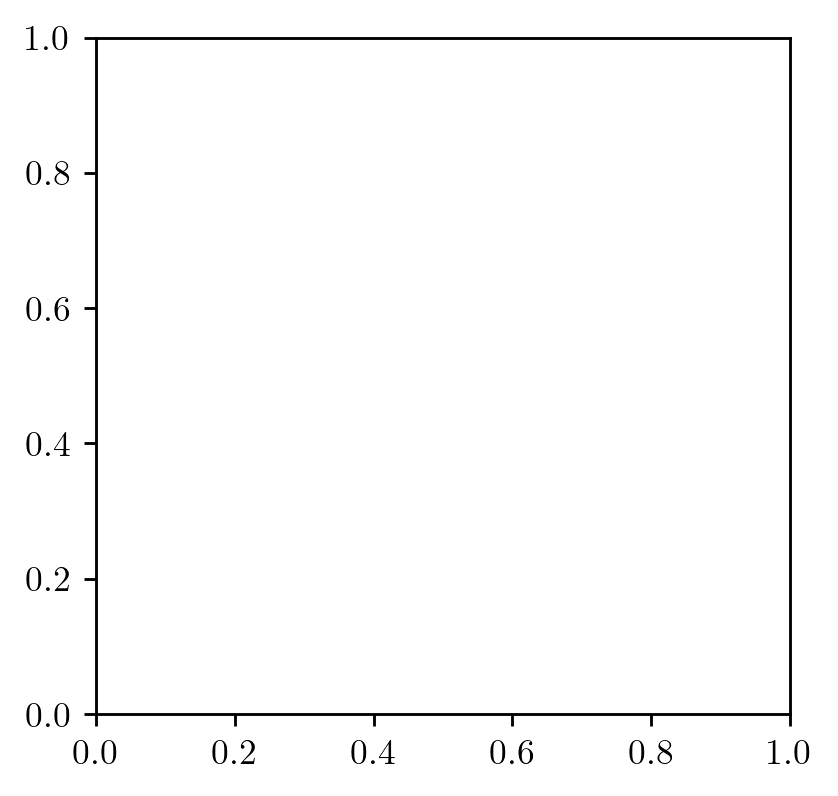

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

lam_E = sp.lambdify(k, Ef.simplify(), modules=['numpy', 'scipy', 'mpmath'])
lam_V = sp.lambdify(s, Vs.simplify(), modules=['numpy', 'scipy', 'mpmath'])

_kk = np.exp(np.linspace(np.log(float(sp_kmin.evalf())), np.log(float(sp_kmax.evalf())), 100))

for _k in _kk:

    if _k > 4.87:
        continue

    _s = np.sqrt(2.)/_k
    num = lam_V(float(_s))
    denom = lam_E(float(_k))
    print(_k, _s, num)
    to_omni = float(S_D.evalf() * _k**(sp_D-1))
    ax.scatter(_k, np.sqrt(_k * to_omni * num), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

    _s = np.sqrt(2.*sp_D + 6.)/(2.*_k)
    num = lam_V(float(_s))
    ax.scatter(_k, np.sqrt(_k * to_omni * num), marker='o', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

    ax.scatter(_k, np.sqrt(_k * to_omni * denom), marker='X', s=5., color=c[2], zorder=0, linewidth=0.2, edgecolor='black')

ax.plot(_kk, 5*_kk**(-1./3.), color='black', linestyle=(0,(5,5)), linewidth=1.5)

ax.loglog()

ax.axvline(float(sp_kmin.evalf()), color='black', linewidth=1., linestyle=(0,(5,5)), zorder=0)
ax.axvline(float(sp_kmax.evalf()), color='black', linewidth=1., linestyle=(0,(5,5)), zorder=0)

ax.axvline(b.evalf(), color='gray', linewidth=1., linestyle=':', zorder=0)

ax.set_ylabel('Bias, $\\tilde{E}(k_{\sigma})/E(k)$')
ax.set_xlabel('Wavenumber, $k_{\sigma}$')